# Case Study: Enhancing Medical Image Details Using Fourier Transform Filtering

This notebook demonstrates how to use Fourier Transform techniques to analyze and filter MRI images in the frequency domain for improved clarity and detail.

## 1. Load MRI Image and Compute Fourier Transform

We will decompose the image into its frequency components and visualize the magnitude and phase spectrum.

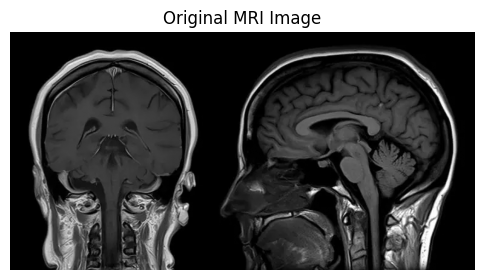

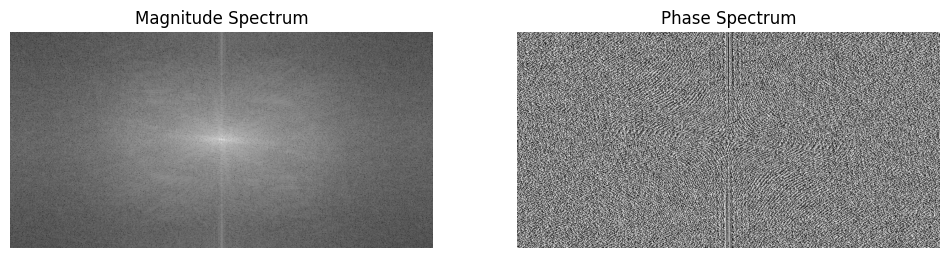

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load MRI image (replace with your filename if needed)
img = cv2.imread('mri.jpeg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise Exception('Image not found!')

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title('Original MRI Image')
plt.axis('off')
plt.show()

# Compute 2D Fourier Transform
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude = np.log(1 + np.abs(fshift))
phase = np.angle(fshift)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(magnitude, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(phase, cmap='gray')
plt.title('Phase Spectrum')
plt.axis('off')
plt.show()

## 2. Frequency Domain Filtering: ILPF and IHPF

Apply Ideal Low Pass and High Pass Filters to the frequency domain and visualize the results.

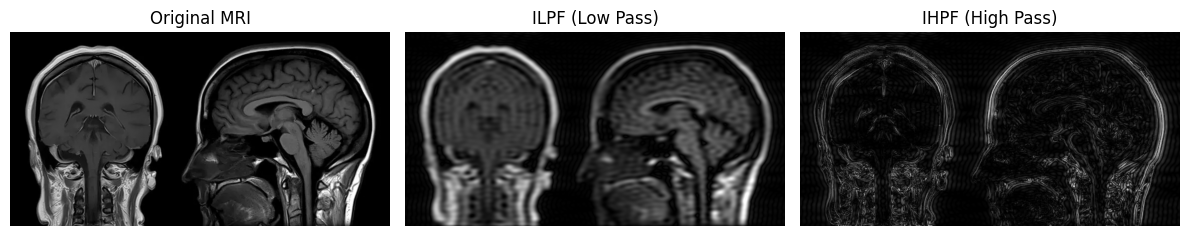

In [2]:
def ideal_low_pass_filter(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols), np.uint8)
    for u in range(rows):
        for v in range(cols):
            if np.sqrt((u-crow)**2 + (v-ccol)**2) <= cutoff:
                mask[u,v] = 1
    return mask

def ideal_high_pass_filter(shape, cutoff):
    return 1 - ideal_low_pass_filter(shape, cutoff)

cutoff = 40  # You can adjust cutoff frequency

# ILPF
ilpf_mask = ideal_low_pass_filter(img.shape, cutoff)
ilpf_fshift = fshift * ilpf_mask
ilpf_img = np.fft.ifft2(np.fft.ifftshift(ilpf_fshift))
ilpf_img = np.abs(ilpf_img)
ilpf_img = np.clip(ilpf_img, 0, 255).astype(np.uint8)

# IHPF
ihpf_mask = ideal_high_pass_filter(img.shape, cutoff)
ihpf_fshift = fshift * ihpf_mask
ihpf_img = np.fft.ifft2(np.fft.ifftshift(ihpf_fshift))
ihpf_img = np.abs(ihpf_img)
ihpf_img = np.clip(ihpf_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original MRI')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(ilpf_img, cmap='gray')
plt.title('ILPF (Low Pass)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(ihpf_img, cmap='gray')
plt.title('IHPF (High Pass)')
plt.axis('off')
plt.tight_layout()

plt.show()

## 3. Interpretation of Results

- **Original Image:** Contains both low-frequency (smooth regions) and high-frequency (edges, fine details) components. Noise and poor contrast may obscure subtle tissue boundaries.
- **Magnitude Spectrum:** Shows the strength of different frequency components. Central bright spot = low frequencies; outer regions = high frequencies.
- **Phase Spectrum:** Encodes spatial information and structure.
- **ILPF (Low Pass):** Smooths the image, reduces noise, but may blur edges and fine details. Useful for noise reduction but can obscure important diagnostic features.
- **IHPF (High Pass):** Enhances edges and fine details, making tissue boundaries clearer. May also amplify noise if present.

**Conclusion:**
- ILPF is best for noise reduction and smoothing, but may reduce diagnostic clarity for fine structures.
- IHPF is best for enhancing edges and boundaries, improving visibility of subtle features, but may increase noise. A balanced approach or combination may be optimal for medical analysis.